In [21]:
import pandas as pd

In [22]:
df=pd.read_csv('youtoxic_english_1000.csv')


In [23]:
df.head()

,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,If only people would just take a step back and...,False,False,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False
2,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\nDont you reckon them 'black lives matter' ba...,True,True,False,False,True,False,False,False,False,False,False,False
3,Ugg7Gd006w1MPngCoAEC,04kJtp6pVXI,There are a very large number of people who do...,False,False,False,False,False,False,False,False,False,False,False,False
4,Ugg8FfTbbNF8IngCoAEC,04kJtp6pVXI,"The Arab dude is absolutely right, he should h...",False,False,False,False,False,False,False,False,False,False,False,False


In [24]:
print(df.columns)

Index(['CommentId', 'VideoId', 'Text', 'IsToxic', 'IsAbusive', 'IsThreat',
       'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist',
       'IsNationalist', 'IsSexist', 'IsHomophobic', 'IsReligiousHate',
       'IsRadicalism'],
      dtype='str')


In [27]:
#clean dataset
import re

def clean_text(text):
    text = text.lower()
    
    text = re.sub(r'\n', ' ', text)        # remove newline
    text = re.sub(r'\r', ' ', text)        # remove carriage return
    text = re.sub(r"http\S+", "", text)    # remove links
    text = re.sub(r"[^a-zA-Z]", " ", text) # remove special chars
    
    text = text.split()
    text = " ".join(text)
    
    return text

df['cleaned'] = df['Text'].apply(clean_text)


In [28]:
df.isna().sum()

CommentId          0
VideoId            0
Text               0
IsToxic            0
IsAbusive          0
IsThreat           0
IsProvocative      0
IsObscene          0
IsHatespeech       0
IsRacist           0
IsNationalist      0
IsSexist           0
IsHomophobic       0
IsReligiousHate    0
IsRadicalism       0
cleaned            0
dtype: int64

In [29]:
df.head()

,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism,cleaned
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,If only people would just take a step back and...,False,False,False,False,False,False,False,False,False,False,False,False,if only people would just take a step back and...
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False,law enforcement is not trained to shoot to app...
2,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\nDont you reckon them 'black lives matter' ba...,True,True,False,False,True,False,False,False,False,False,False,False,dont you reckon them black lives matter banner...
3,Ugg7Gd006w1MPngCoAEC,04kJtp6pVXI,There are a very large number of people who do...,False,False,False,False,False,False,False,False,False,False,False,False,there are a very large number of people who do...
4,Ugg8FfTbbNF8IngCoAEC,04kJtp6pVXI,"The Arab dude is absolutely right, he should h...",False,False,False,False,False,False,False,False,False,False,False,False,the arab dude is absolutely right he should ha...


In [30]:
#delete unnecessary column
df = df.drop(['CommentId', 'VideoId'], axis=1)

In [31]:
#combine all toxic .... column into 1 column final label
toxic_cols = [
    'IsToxic', 'IsAbusive', 'IsThreat',
    'IsProvocative', 'IsObscene', 'IsHatespeech',
    'IsRacist', 'IsNationalist', 'IsSexist',
    'IsHomophobic', 'IsReligiousHate', 'IsRadicalism'
]

df['FinalLabel'] = df[toxic_cols].max(axis=1)

In [32]:
df.head()

,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism,cleaned,FinalLabel
0,If only people would just take a step back and...,False,False,False,False,False,False,False,False,False,False,False,False,if only people would just take a step back and...,False
1,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False,law enforcement is not trained to shoot to app...,True
2,\nDont you reckon them 'black lives matter' ba...,True,True,False,False,True,False,False,False,False,False,False,False,dont you reckon them black lives matter banner...,True
3,There are a very large number of people who do...,False,False,False,False,False,False,False,False,False,False,False,False,there are a very large number of people who do...,False
4,"The Arab dude is absolutely right, he should h...",False,False,False,False,False,False,False,False,False,False,False,False,the arab dude is absolutely right he should ha...,False


In [33]:
#devide test and train data
from sklearn.model_selection import train_test_split
X_text = df['cleaned']
y = df['FinalLabel']
#here strarify=y means devide same data for both means without it might posibble to 
# go mostly all noon toxic data into  training and less in toxic
#with this it spit mostly even
 
x_train, x_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)
print("Training data",x_train.shape)
print("Test data",x_test.shape)

Training data (800,)
Test data (200,)


In [34]:
#split the full paragraph or sentence  into indivisual word
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

#conver the train and test data into numeric
X_train = vectorizer.fit_transform(x_train)
X_test = vectorizer.transform(x_test)
print(X_train.shape)
print(X_test.shape)
#here 800 and 200 are row
#and 3956 is total word

(800, 3956)
(200, 3956)


In [35]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,cohen_kappa_score

In [36]:
def func(y_test,y_pred):
    cr=classification_report(y_test,y_pred)
    cm=confusion_matrix(y_test,y_pred)
    ac=accuracy_score(y_test,y_pred)
    ks=cohen_kappa_score(y_test,y_pred)
    err=1-ac
    print("confusion_matrix",cm)
    print("accuracy_score",ac)
    print("Error rate",err)
    print("classification_report",cr)
    print("cohen_kappa_score",ks)




#train model now

In [37]:
#linear regression model
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression")
func(y_test, y_pred_lr)

Logistic Regression
confusion_matrix [[95 13]
 [45 47]]
accuracy_score 0.71
Error rate 0.29000000000000004
classification_report               precision    recall  f1-score   support

       False       0.68      0.88      0.77       108
        True       0.78      0.51      0.62        92

    accuracy                           0.71       200
   macro avg       0.73      0.70      0.69       200
weighted avg       0.73      0.71      0.70       200

cohen_kappa_score 0.40082644628099184


In [38]:
#naive model
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("\nNaive Bayes")
func(y_test, y_pred_nb)


Naive Bayes
confusion_matrix [[95 13]
 [52 40]]
accuracy_score 0.675
Error rate 0.32499999999999996
classification_report               precision    recall  f1-score   support

       False       0.65      0.88      0.75       108
        True       0.75      0.43      0.55        92

    accuracy                           0.68       200
   macro avg       0.70      0.66      0.65       200
weighted avg       0.70      0.68      0.66       200

cohen_kappa_score 0.3246051537822112


In [39]:
#svc
from sklearn.svm import SVC

svm = SVC(probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("\nSVM")
func(y_test, y_pred_svm)


SVM
confusion_matrix [[98 10]
 [51 41]]
accuracy_score 0.695
Error rate 0.30500000000000005
classification_report               precision    recall  f1-score   support

       False       0.66      0.91      0.76       108
        True       0.80      0.45      0.57        92

    accuracy                           0.69       200
   macro avg       0.73      0.68      0.67       200
weighted avg       0.72      0.69      0.68       200

cohen_kappa_score 0.3651124063280601


In [40]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("\nDecision Tree")
func(y_test, y_pred_dt)


Decision Tree
confusion_matrix [[80 28]
 [41 51]]
accuracy_score 0.655
Error rate 0.345
classification_report               precision    recall  f1-score   support

       False       0.66      0.74      0.70       108
        True       0.65      0.55      0.60        92

    accuracy                           0.66       200
   macro avg       0.65      0.65      0.65       200
weighted avg       0.65      0.66      0.65       200

cohen_kappa_score 0.29820992676973146


In [41]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\nRandom Forest")
func(y_test, y_pred_rf)


Random Forest
confusion_matrix [[101   7]
 [ 54  38]]
accuracy_score 0.695
Error rate 0.30500000000000005
classification_report               precision    recall  f1-score   support

       False       0.65      0.94      0.77       108
        True       0.84      0.41      0.55        92

    accuracy                           0.69       200
   macro avg       0.75      0.67      0.66       200
weighted avg       0.74      0.69      0.67       200

cohen_kappa_score 0.36192468619246854


In [42]:
#Get probablity
y_prob_lr = lr.predict_proba(X_test)[:,1]
y_prob_nb = nb.predict_proba(X_test)[:,1]
y_prob_rf = rf.predict_proba(X_test)[:,1]
y_prob_dt = dt.predict_proba(X_test)[:,1]
y_prob_svm = svm.predict_proba(X_test)[:,1]

In [43]:
#now roc and  auc
# ROC Curve = performance at different thresholds#
# AUC = overall performance score (0 → 1)
#AUC	  Meaning
#1.0	  perfect
#0.9+  excellent 
#0.8	  good
#0.5   random

from sklearn.metrics import roc_auc_score,roc_curve


# ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# AUC
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_nb = roc_auc_score(y_test, y_prob_nb)
auc_svm = roc_auc_score(y_test, y_prob_svm)
auc_dt = roc_auc_score(y_test, y_prob_dt)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("AUC LR:", auc_lr)
print("AUC NB:", auc_nb)
print("AUC SVM:", auc_svm)
print("AUC DT:", auc_dt)
print("AUC RF:", auc_rf)


AUC LR: 0.785426731078905
AUC NB: 0.7620772946859904
AUC SVM: 0.770330112721417
AUC DT: 0.6475442834138486
AUC RF: 0.7969504830917874


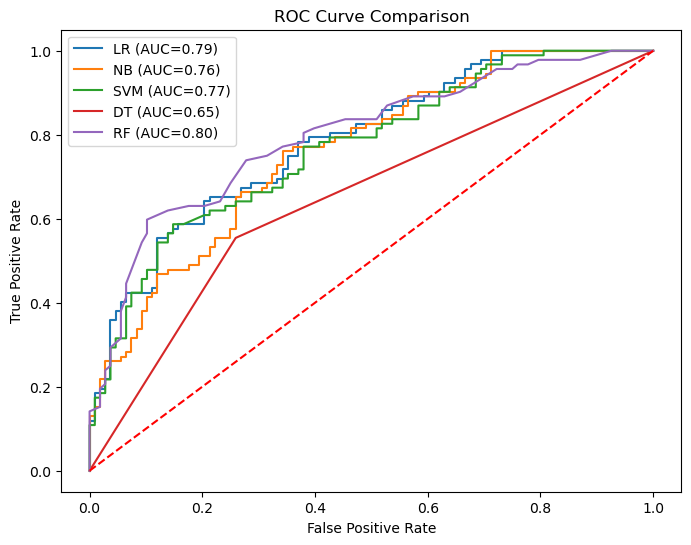

In [44]:
#roc curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label=f'LR (AUC={auc_lr:.2f})')
plt.plot(fpr_nb, tpr_nb, label=f'NB (AUC={auc_nb:.2f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC={auc_svm:.2f})')
plt.plot(fpr_dt, tpr_dt, label=f'DT (AUC={auc_dt:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'RF (AUC={auc_rf:.2f})')

plt.plot([0,1], [0,1], 'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

In [ ]:
#saves your trained model into a file
import joblib

joblib.dump(rf, "model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl") 

['vectorizer.pkl']